### Conceptual

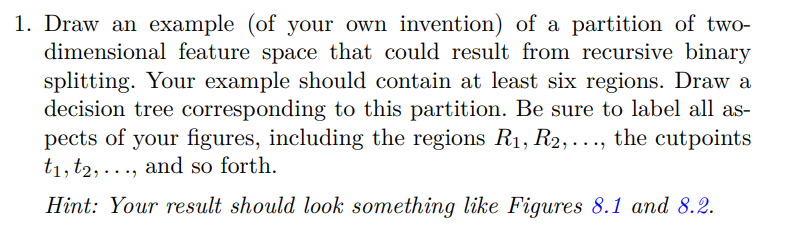

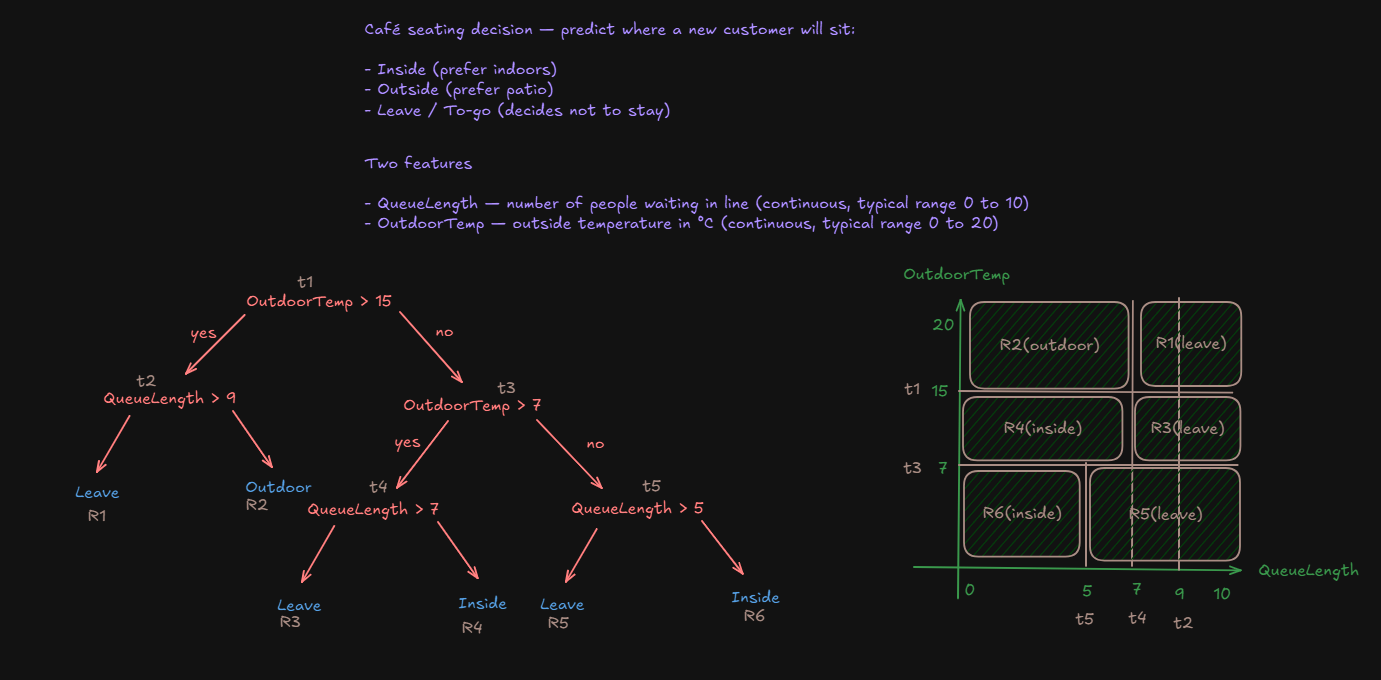

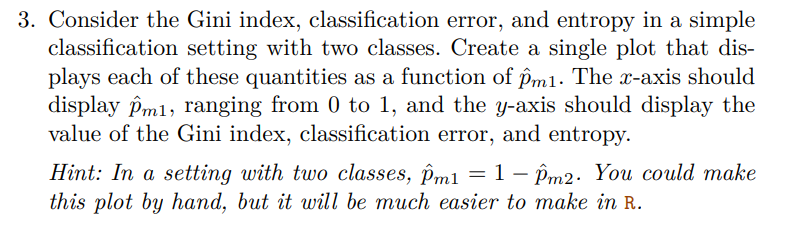

Gini index:
$$G_m = 1 - \sum_{k=1}^{K} \hat{p}_{mk}^2$$

Entropy:
$$D_m = -\sum_{k=1}^{K} \hat{p}_{mk} \log(\hat{p}_{mk})$$

Classification error:
$$E_m = 1 - \max_k (\hat{p}_{mk})$$

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def gini_index(p_1):
  prop = np.array([p_1, 1 - p_1])
  return 1 - np.sum(prop**2)

def entropy(p_1):
  prop = np.array([p_1, 1 - p_1])
  return -np.sum([pi * np.log(pi) for pi in prop])

def classification_error(p_1):
  return 1 - max(p_1, 1 - p_1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15720\574197226.py:7: RuntimeWarning: divide by zero encountered in log
  return -np.sum([pi * np.log(pi) for pi in prop])
C:\Users\Admin\AppData\Local\Temp\ipykernel_15720\574197226.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  return -np.sum([pi * np.log(pi) for pi in prop])


[]

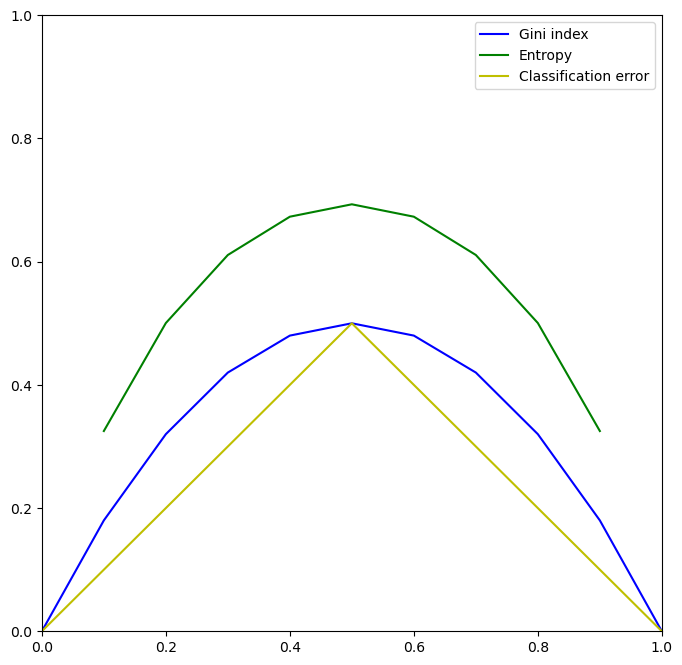

In [9]:
ax = plt.subplots(figsize=(8, 8))[1]

p_1 = np.linspace(0, 1, 11)
gini_values = [gini_index(pi) for pi in p_1]
entropy_values = [entropy(pi) for pi in p_1]
classification_error_values = [classification_error(pi) for pi in p_1]

ax.plot(p_1, gini_values, c="b", label="Gini index")
ax.plot(p_1, entropy_values, c="g", label="Entropy")
ax.plot(p_1, classification_error_values, c="y", label="Classification error")

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot()

They all have an inverted U-shape, which makes sense because a node is most impure when the class proportion is 0.5, while it is pure when the proportion is 0 or 1.

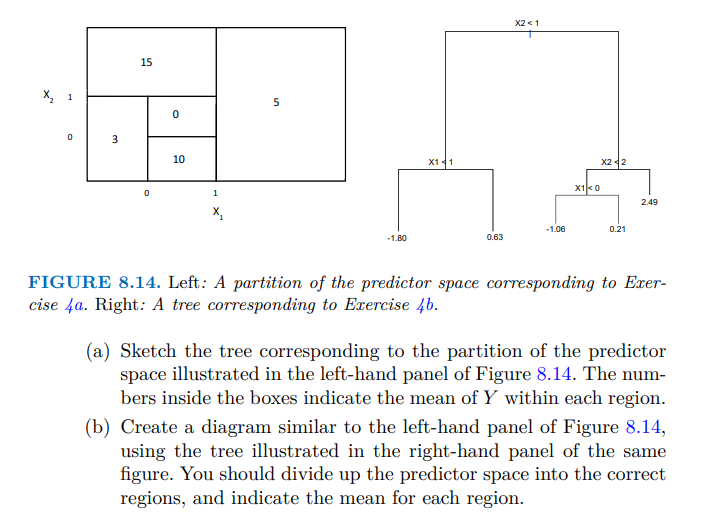

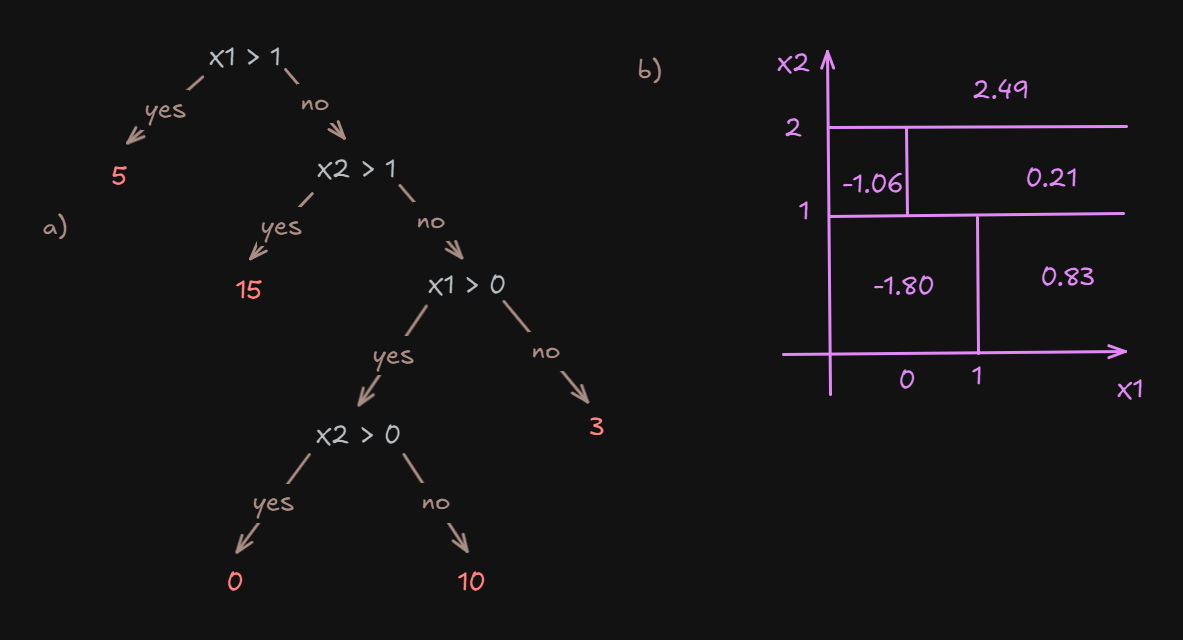

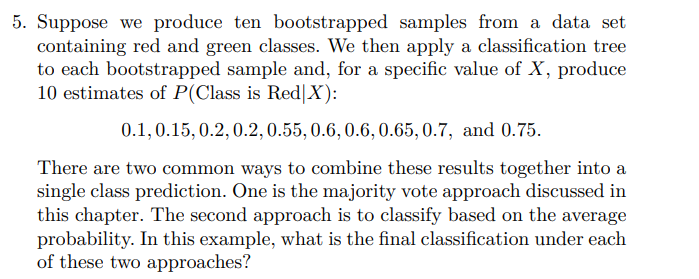

In [18]:
def majority_vote(decisions):
  vote_for_0 = (decisions < 0.5).sum()
  vote_for_1 = (decisions > 0.5).sum()
  
  return 0 if vote_for_0 > vote_for_1 else 1

In [19]:
def average_prob_classifier(decisions):
  return 0 if decisions.mean() < 0.5 else 0

In [21]:
decisions = np.array([0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75])

print("1. ", majority_vote(decisions))
print("2. ", average_prob_classifier(decisions))

1.  1
2.  0


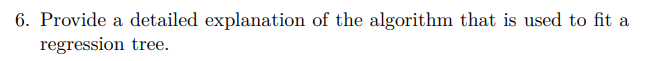

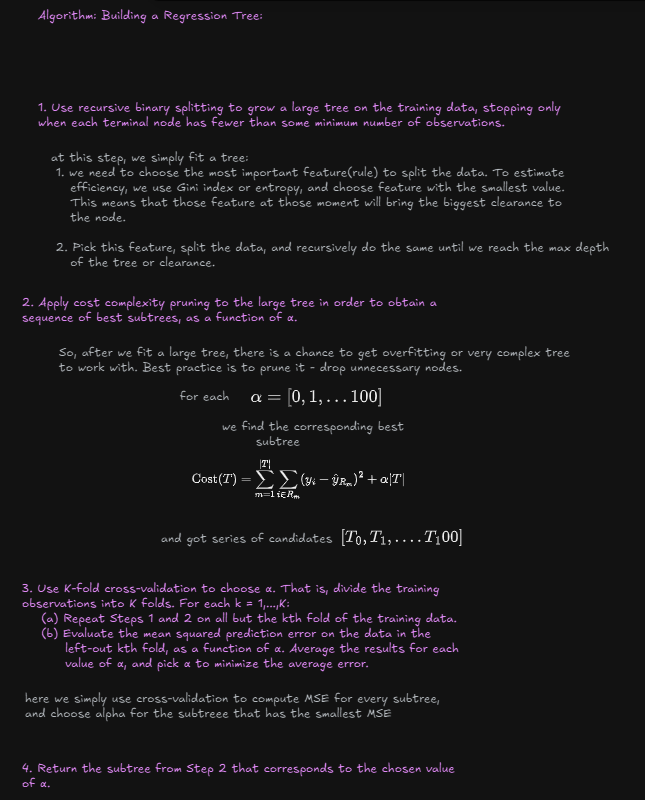

### Applied

In [22]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART

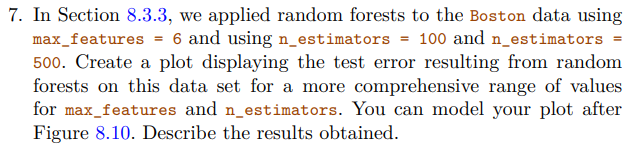

In [23]:
boston = load_data("Boston")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [24]:
boston.shape

(506, 13)

In [29]:
X = boston.drop("medv", axis=1)
y = boston["medv"]

In [31]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        y,
                                                        test_size=0.3,
                                                        random_state=0)

So, for RandomForest we have to main hyperparameters:
- max_features - number of random features per tree
- n_estimators - number of trees in ensemble

In [46]:
RF_model = RF(random_state=0)

In [56]:
K  = 5
kfold = skm.KFold(n_splits=K,
                  random_state=0,
                  shuffle=True)

# m - subset size of features(p) in a tree
p = X_train.shape[1]

param_grid = {
  "n_estimators": np.linspace(0, 3000, 11).astype(int),
  "max_features": [1, int(np.sqrt(p)), p // 2, p]  
}

grid = skm.GridSearchCV(estimator=RF_model,
                        cv=kfold,
                        param_grid=param_grid,
                        scoring="neg_mean_squared_error")

grid.fit(X, y)

KeyboardInterrupt: 

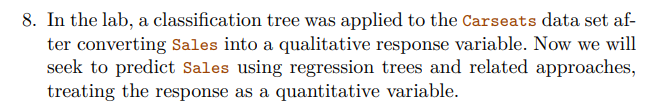

In [58]:
carseats = load_data("Carseats")
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


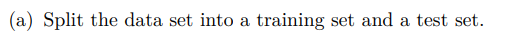

In [72]:
model = MS(X.columns, intercept=False)
D = model.fit_transform(carseats)
feature_names = list(D.columns)
X = np.asarray(D)
y = carseats["Sales"]

In [73]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        y, 
                                                        test_size=0.3, 
                                                        random_state=0)

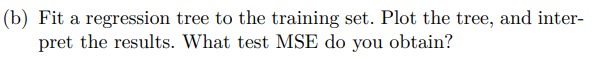

In [80]:
regr_tree_model = DTR(max_depth=3)
regr_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [81]:
regr_tree_model.tree_.max_depth

3

[Text(0.5, 0.875, 'ShelveLoc[Good] <= 0.5\nsquared_error = 8.438\nsamples = 280\nvalue = 7.378'),
 Text(0.25, 0.625, 'ShelveLoc[Medium] <= 0.5\nsquared_error = 6.26\nsamples = 226\nvalue = 6.705'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Price <= 102.5\nsquared_error = 5.251\nsamples = 71\nvalue = 5.159'),
 Text(0.0625, 0.125, 'squared_error = 4.795\nsamples = 21\nvalue = 6.697'),
 Text(0.1875, 0.125, 'squared_error = 4.031\nsamples = 50\nvalue = 4.512'),
 Text(0.375, 0.375, 'Price <= 106.5\nsquared_error = 5.127\nsamples = 155\nvalue = 7.413'),
 Text(0.3125, 0.125, 'squared_error = 4.149\nsamples = 55\nvalue = 8.743'),
 Text(0.4375, 0.125, 'squared_error = 4.156\nsamples = 100\nvalue = 6.681'),
 Text(0.75, 0.625, 'Price <= 107.5\nsquared_error = 7.698\nsamples = 54\nvalue = 10.198'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Age <= 55.5\nsquared_error = 3.888\nsamples = 20\nvalue = 12.344'),
 Text(0.5625, 0.125, 'squared_error = 2.928\nsamples = 11\nvalue = 13.395

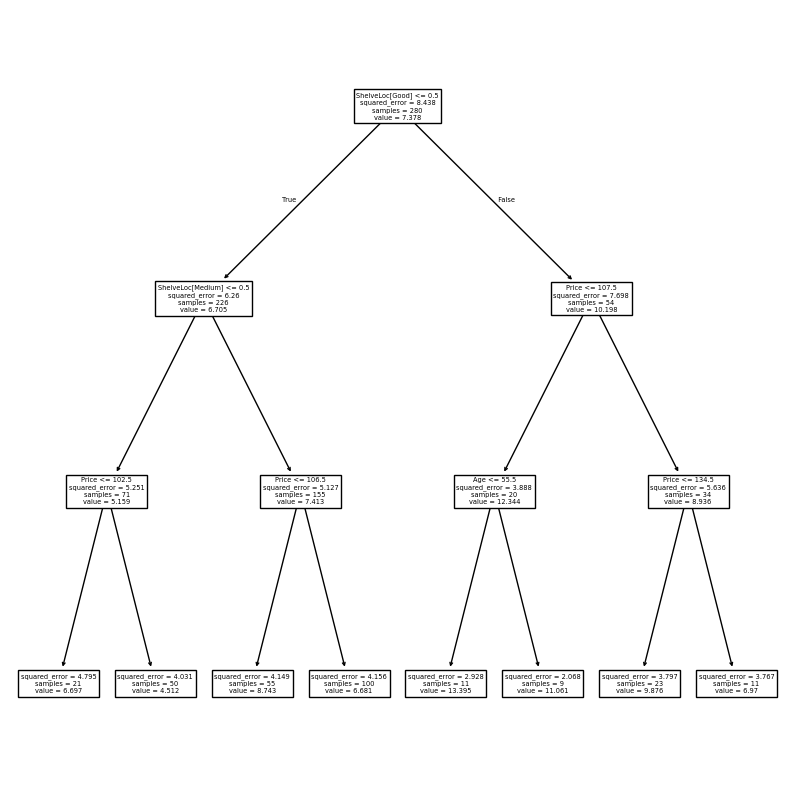

In [82]:
fig, ax = subplots(figsize=(10, 10))

plot_tree(ax=ax,
          decision_tree=regr_tree_model, 
          feature_names=feature_names)

In [86]:
y_pred = regr_tree_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  3.703858275236093
test RMSE:  1.9245410557418858


So, from tree we see that `ShelveLoc` and `Price` are probably the most important features

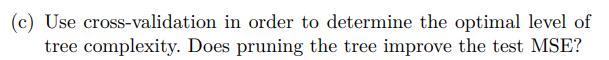

In [87]:
ccp_path = regr_tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_path

{'ccp_alphas': array([0.        , 0.09625833, 0.22444027, 0.25210042, 0.52253297,
        0.53848613, 0.88359258, 1.90014702]),
 'impurities': array([4.02025696, 4.1165153 , 4.34095557, 4.59305599, 5.11558896,
        5.65407509, 6.53766767, 8.43781468])}

In [89]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "ccp_alpha": ccp_path.ccp_alphas
}

grid = skm.GridSearchCV(estimator=regr_tree_model,
                        cv=kfold,
                        scoring="neg_mean_squared_error",
                        param_grid=param_grid)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=DecisionTreeRegressor(max_depth=3),
             param_grid={'ccp_alpha': array([0.        , 0.09625833, 0.22444027, 0.25210042, 0.52253297,
       0.53848613, 0.88359258, 1.90014702])},
             scoring='neg_mean_squared_error')

In [91]:
tuned_tree_model = grid.best_estimator_

In [92]:
tuned_tree_model.tree_.max_depth

3

In [93]:
y_pred = tuned_tree_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  3.7038582752360942
test RMSE:  1.9245410557418863


The error did not change, so pruning does not bring some improvements

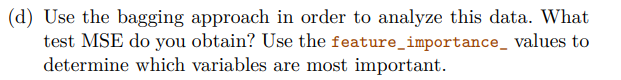

In [96]:
# as we remember: bagging is a special case of random forest, when p = m

bagging_model = RF(max_features=X_train.shape[1], n_estimators=500, random_state=0)
bagging_model.fit(X_train, y_train)

RandomForestRegressor(max_features=11, n_estimators=500, random_state=0)

In [97]:
y_pred = bagging_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  2.0236328641333428
test RMSE:  1.4225445033928965


We see improvement of MSE: 3.703 ---> 2.02

In [100]:
feature_imp = pd.DataFrame({
  "importance": bagging_model.feature_importances_
}, index=feature_names)

feature_imp.sort_values(by="importance", ascending=False)

,importance
Price,0.286600
ShelveLoc[Good],0.220007
Age,0.105353
CompPrice,0.100679
ShelveLoc[Medium],0.085092
Advertising,0.068876
Income,0.053628
Population,0.039242
Education,0.029639
US[Yes],0.006542


As i said earlier, `Pirce` and `ShelveLoc` are the most important features

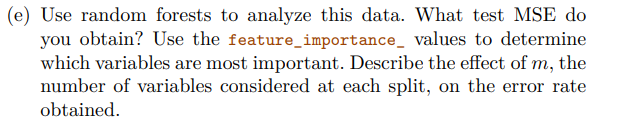

In [101]:
rand_forest_model = RF()

In [108]:
K = 5
kfold = skm.KFold(n_splits=K,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "max_features": np.linspace(1, X_train.shape[1], X_train.shape[1]).astype(int)
}

grid = skm.GridSearchCV(estimator=rand_forest_model,
                        param_grid=param_grid,
                        scoring="neg_mean_squared_error",
                        cv=kfold)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=RandomForestRegressor(),
             param_grid={'max_features': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])},
             scoring='neg_mean_squared_error')

In [110]:
grid.cv_results_["param_max_features"]

masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999)

In [111]:
grid.cv_results_["mean_test_score"]

array([-4.73224084, -3.81627447, -3.31665591, -3.13139801, -3.02921988,
       -2.92061926, -2.77234383, -2.78568701, -2.80635447, -2.73602022,
       -2.72396336])

Text(0, 0.5, 'MSE')

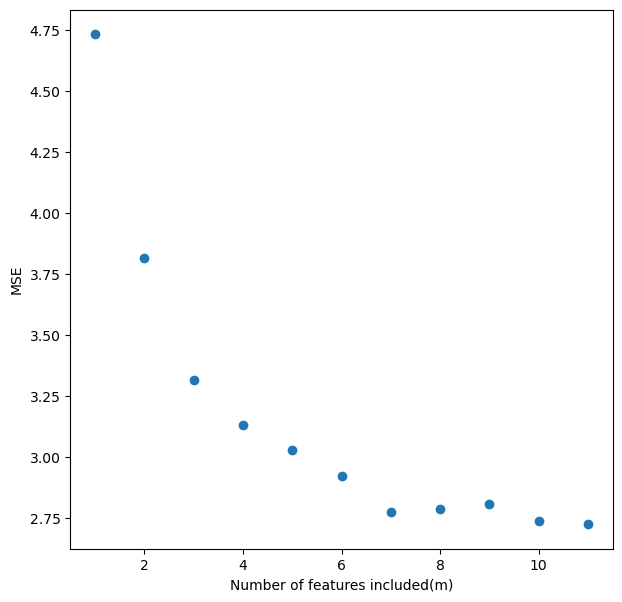

In [ ]:
fig, ax = subplots(figsize=(7, 7))
ax.scatter(grid.cv_results_["param_max_features"],
           -grid.cv_results_["mean_test_score"])
ax.set_xlabel("Number of features included(m)")
ax.set_ylabel("MSE")

In [118]:
tuned_rand_for_model = grid.best_estimator_

In [119]:
y_pred = tuned_rand_for_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  1.9384918794166663
test RMSE:  1.392297338723545


Random forest has slightly better results than bagging model

In [121]:
feature_imp = pd.DataFrame(
  {"importance": tuned_rand_for_model.feature_importances_},
  index=feature_names
)
feature_imp.sort_values(by="importance", ascending=False)

,importance
Price,0.284589
ShelveLoc[Good],0.228241
Age,0.100333
CompPrice,0.095656
ShelveLoc[Medium],0.089838
Advertising,0.068499
Income,0.054139
Population,0.036443
Education,0.031064
US[Yes],0.007099


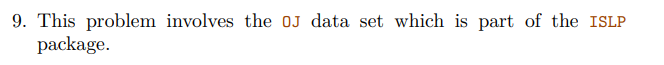

In [122]:
oj = load_data("OJ")
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [123]:
oj.shape

(1070, 18)

In [124]:
oj.describe()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,254.381308,3.959813,1.867421,2.085411,0.051860,0.123364,0.147664,0.161682,0.565782,1.962047,1.815561,0.146486,0.059298,0.027314,0.217991,1.630841
std,15.558286,2.308984,0.101970,0.134386,0.117474,0.213834,0.354932,0.368331,0.307843,0.252697,0.143384,0.271563,0.101760,0.062232,0.107535,1.430387
min,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,0.000000,0.000000,0.000000,0.000000
25%,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.325257,1.690000,1.750000,0.000000,0.000000,0.000000,0.140000,0.000000
50%,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,0.000000,0.000000,0.240000,2.000000
75%,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850873,2.130000,1.890000,0.320000,0.112676,0.000000,0.300000,3.000000
max,278.000000,7.000000,2.090000,2.290000,0.500000,0.800000,1.000000,1.000000,0.999947,2.290000,2.090000,0.640000,0.402010,0.252688,0.440000,4.000000


In [125]:
oj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Purchase        1070 non-null   category
 1   WeekofPurchase  1070 non-null   int64   
 2   StoreID         1070 non-null   int64   
 3   PriceCH         1070 non-null   float64 
 4   PriceMM         1070 non-null   float64 
 5   DiscCH          1070 non-null   float64 
 6   DiscMM          1070 non-null   float64 
 7   SpecialCH       1070 non-null   int64   
 8   SpecialMM       1070 non-null   int64   
 9   LoyalCH         1070 non-null   float64 
 10  SalePriceMM     1070 non-null   float64 
 11  SalePriceCH     1070 non-null   float64 
 12  PriceDiff       1070 non-null   float64 
 13  Store7          1070 non-null   category
 14  PctDiscMM       1070 non-null   float64 
 15  PctDiscCH       1070 non-null   float64 
 16  ListPriceDiff   1070 non-null   float64 
 17  STORE         

In [127]:
oj["Purchase"].value_counts()

Purchase
CH    653
MM    417
Name: count, dtype: int64

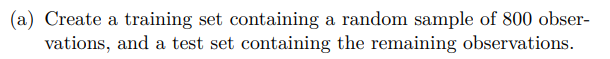

In [140]:
model = MS(oj.drop("Purchase", axis=1).columns, intercept=False)
D = model.fit_transform(oj)
X = np.asarray(D)
y = np.where(oj["Purchase"] == "CH", 1, 0)

feature_names = list(D.columns)

In [141]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, 
                                                        y, 
                                                        test_size= 1 - (800 * 100 / X.shape[0]) / 100, 
                                                        random_state=0)

In [142]:
X_train.shape

(799, 17)

Since `Purchase` is a categorical response, we will use classification decision tree

In [146]:
class_tree = DTC(random_state=0)
class_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [156]:
y_pred = class_tree.predict(X_train)
1 - accuracy_score(y_train, y_pred)

0.008760951188986232

Very small traning error rate

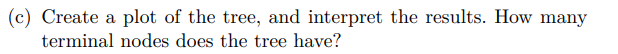

[Text(0.522198275862069, 0.96875, 'LoyalCH <= 0.509\ngini = 0.469\nsamples = 799\nvalue = [300.0, 499.0]'),
 Text(0.22198275862068967, 0.90625, 'LoyalCH <= 0.282\ngini = 0.413\nsamples = 340\nvalue = [241, 99]'),
 Text(0.3720905172413793, 0.9375, 'True  '),
 Text(0.07974137931034483, 0.84375, 'LoyalCH <= 0.062\ngini = 0.237\nsamples = 160\nvalue = [138, 22]'),
 Text(0.027586206896551724, 0.78125, 'StoreID <= 1.5\ngini = 0.064\nsamples = 60\nvalue = [58, 2]'),
 Text(0.013793103448275862, 0.71875, 'ListPriceDiff <= 0.15\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.006896551724137931, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.020689655172413793, 0.65625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.041379310344827586, 0.71875, 'WeekofPurchase <= 268.5\ngini = 0.034\nsamples = 57\nvalue = [56, 1]'),
 Text(0.034482758620689655, 0.65625, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.04827586206896552, 0.65625, 'LoyalCH <= 0.001\ngini = 0.219\nsample

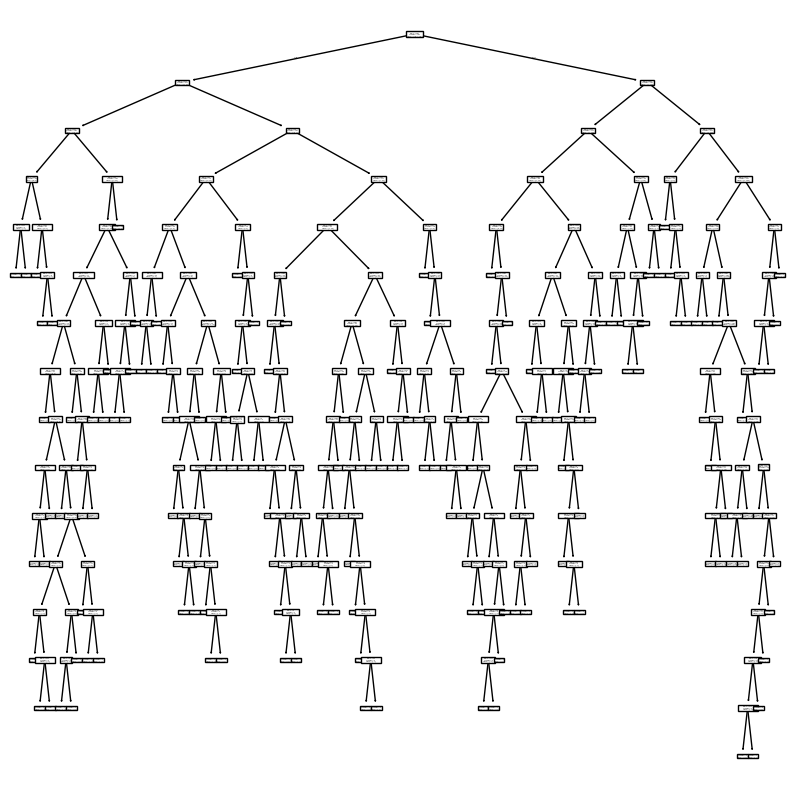

In [157]:
fig, ax = subplots(figsize=(10, 10))
plot_tree(
  ax=ax,
  feature_names=feature_names,
  decision_tree=class_tree
)

Wow.....a tiny number of terminal nodes in a tree

In [161]:
class_tree.get_n_leaves()

np.int64(161)